In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil, sys
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

sys.path.append("../")
# import mpscr_models as mpscr
import mpscr_models_flexible as mpscr
import pwexp_flexible as pwexp
import gndr_utils as utils
import mps

E0000 00:00:1784830355.328899   17036 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784830355.334978   17036 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784830355.348652   17036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784830355.348679   17036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784830355.348681   17036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784830355.348683   17036 computation_placer.cc:177] computation placer already registered. Please check linka

Thetaflow version: 0.0.35


I0000 00:00:1784830358.084201   17036 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4355 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784830358.122788   17036 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4355 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784830358.169235   17036 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4355 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784830358.170439   17036 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4355 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784830358.172246   17036 gpu_device.cc:2019] Cr

# Load data

In [2]:
df = pd.read_csv("OASIS Data/patients_full_data.csv")
print("Data dimensions: {}".format(df.shape))
df.head(3)

Data dimensions: (737, 277)


,oasis_id,time_days,delta,age_at_entry,age_at_death,gender,apoe,days_to_visit,age_at_visit,cdr,...,vol_wm_rh_superiorfrontal,vol_wm_rh_superiorparietal,vol_wm_rh_superiortemporal,vol_wm_rh_supramarginal,vol_wm_rh_frontalpole,vol_wm_rh_temporalpole,vol_wm_rh_transversetemporal,vol_wm_rh_insula,vol_left_unsegmented_white_matter,vol_right_unsegmented_white_matter
0,OAS30001,5055,0,65.1945,NaN,2,23.0,5184,79.40,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OAS30002,2590,0,67.2521,76.9397,1,34.0,2961,75.36,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OAS30003,5093,0,58.8137,NaN,2,33.0,5651,74.30,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


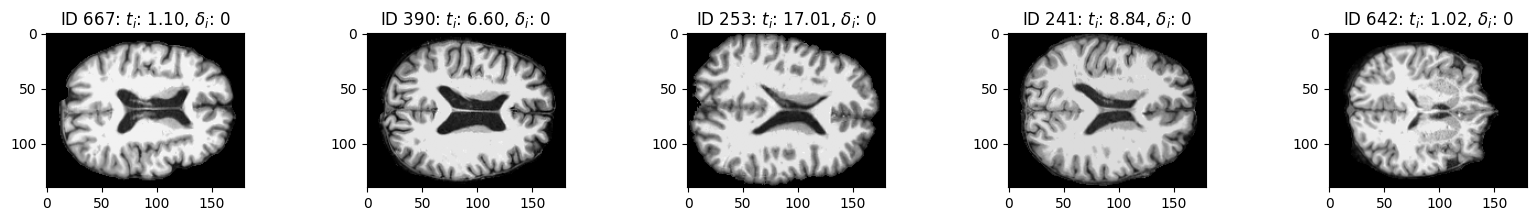

In [3]:
x = np.load("OASIS Data/patients_images.npy")
x = np.expand_dims(x, axis=-1)

np.random.seed(12)

random_idx = np.random.choice(np.arange(x.shape[0]), size = 5)

fig, ax = plt.subplots(nrows = 1, ncols = 5, figsize = (20,2))

for i, a in enumerate(ax):
    idx = random_idx[i]
    a.imshow(x[idx,:,:,0], cmap = "gray")
    a.set_title(r"ID {}: $t_i$: {:.2f}, $\delta_i$: {}".format(idx, df.loc[idx, "time_days"] / 365, df.loc[idx, "delta"]))

In [4]:
from sklearn.model_selection import train_test_split

indices = np.arange(df.shape[0])
idx_train, idx_test = train_test_split(indices, train_size = 0.7, random_state = 42, stratify = delta_train)

print("Train dimension: {}".format(idx_train.shape))
print("Test dimension: {}".format(idx_test.shape))

y_train = df.loc[idx_train, "time_days"] / 365
y_test = df.loc[idx_test, "time_days"] / 365
delta_train = df.loc[idx_train, "delta"]
delta_test = df.loc[idx_test, "delta"]

x_train = x[idx_train]
x_test = x[idx_test]

Train dimension: (515,)
Test dimension: (222,)


### Plot functions

The function below plot the Kaplan-Meier estimates alongside the patients individual survival curves for both censored and susceptible patients. The censored KAplan-Meier will always be constant at 1. The function returns both plots for the train and test data sets.

In [5]:
def plot_censored_susceptible(model_results, ax1 = None, ax2 = None, ax3 = None, ax4 = None, show_individual = True, plot_km = True, color = "red"):
    ts_grid = model_results["ts_grid"]

    delta_train = model_results["delta_train"]
    delta_test = model_results["delta_test"]
    
    p_train = model_results["p_train"]
    p_test = model_results["p_test"]
    
    S_ts_train = model_results["S_ts_train"]
    S_ts_test = model_results["S_ts_test"]

    if(p_train.shape[0] > 1):
        S_ts_train_censored = S_ts_train[delta_train == 0, :]
        S_ts_train_uncensored = (S_ts_train[delta_train == 1, :] - p_train[delta_train == 1]) / (1-p_train[delta_train == 1])

        S_ts_test_censored = S_ts_test[delta_test == 0, :]
        S_ts_test_uncensored = (S_ts_test[delta_test == 1, :] - p_test[delta_test == 1]) / (1-p_test[delta_test == 1])
    else:
        S_ts_train_censored = S_ts_train
        S_ts_train_uncensored = (S_ts_train - p_train) / (1-p_train)

        S_ts_test_censored = S_ts_test
        S_ts_test_uncensored = (S_ts_test - p_test) / (1-p_test)

    fresh_plot = False
    if(ax1 is None or ax2 is None or ax3 is None or ax4 is None):
        fresh_plot = True
        fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,6))
        ax1 = ax[0,0]
        ax2 = ax[0,1]
        ax3 = ax[1,0]
        ax4 = ax[1,1]
    
    utils.average_kaplan_meier(ts_grid,
                               S_ts_train_censored,
                               y_train[delta_train == 0], delta_train[delta_train == 0], show_individual = show_individual, ax = ax1, color = color)
    ax1.set_title("Train set censored")
    
    utils.average_kaplan_meier(ts_grid,
                               S_ts_train_uncensored,
                               y_train[delta_train == 1], delta_train[delta_train == 1], show_individual = show_individual, ax = ax2, color = color)
    ax2.set_title("Train set uncensored")


    utils.average_kaplan_meier(ts_grid,
                               S_ts_test_censored,
                               y_test[delta_test == 0], delta_test[delta_test == 0], show_individual = show_individual, ax = ax3, color = color)
    ax3.set_title("Test set censored")
    
    utils.average_kaplan_meier(ts_grid,
                               S_ts_test_uncensored,
                               y_test[delta_test == 1], delta_test[delta_test == 1], show_individual = show_individual, ax = ax4, color = color)
    ax4.set_title("Test set uncensored")

    if(fresh_plot):
        fig.tight_layout()

### Simple model

Here, we consider the MPScr with no covariates. That is, we assume the cure probability and both parameters from the chosen distribution (from the MPS family) to be global constants. The main interest in fitting this model is in assessing whether the brain MR images are, in fact, bringing new information to the study of the lifetimes.

In [6]:
poisson_spec = mpscr.MPSPoisson()
pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = 8)

data_train = [y_train, delta_train]

with tf.device("/CPU:0"):
    poisson_simple_model = mpscr.build_simple_mpscr_model(y_train, delta_train, poisson_spec, pwexp_spec, seed = 10 )
    poisson_simple_model.train_model(epochs = 5000, x = None, data = data_train,
                                     shuffle = True,
                                     get_covariances = True,
                                     validation = True, val_prop = 0.2, force_training_validation = False,
                                     optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                     optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                                     fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                     early_stopping = True, early_stopping_patience = 50,
                                     early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                                     reduce_lr = True, reduce_lr_warmup = 0,
                                     reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                                     reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                     fine_tune = True,
                                     finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                                     finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                                     finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                     finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                                     finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                     deterministic = True,
                                     verbose = True, print_freq = 1)
    poisson_simple_results = poisson_simple_model.get_survival_cure(y_train, delta_train, y_test, delta_test, ngrid = 100)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1192 / 5000 ]  | Avg. Train NLL:  0.442845 | Avg. Validation NLL:  0.389946312 | Best Avg. Validation NLL:  0.389946312 | Speed:  0.00161604933  epoch/s    | Elapsed Time:  1.9263308  s   s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 10.215 seconds.


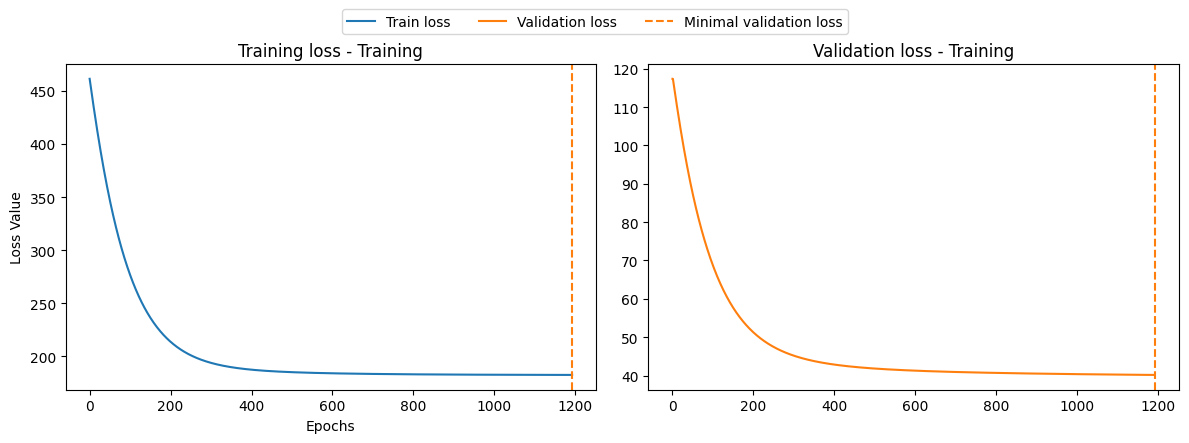

In [7]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
utils.plot_model_convergence( poisson_simple_model, ax1 = ax[0], ax2 = ax[1] )

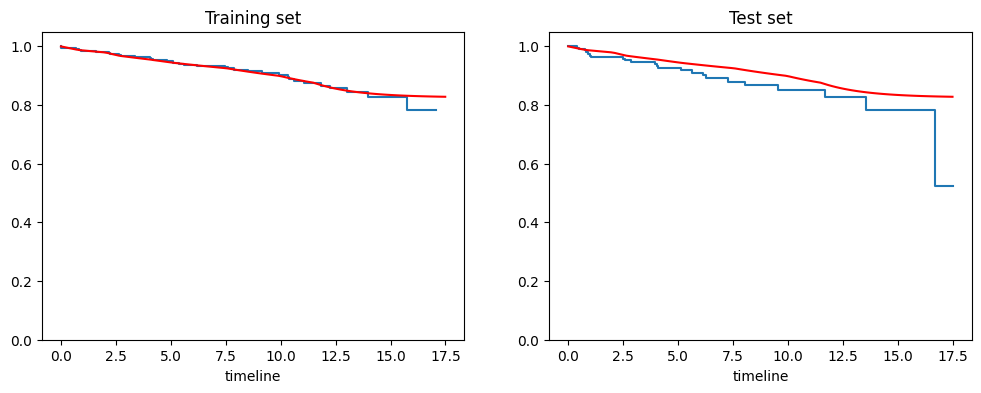

In [8]:
ts_grid = poisson_simple_results["ts_grid"]
p_train = poisson_simple_results["p_train"]
p_test = poisson_simple_results["p_test"]
S_ts_train = poisson_simple_results["S_ts_train"]
S_ts_test = poisson_simple_results["S_ts_test"]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.average_kaplan_meier_train_test(ts_grid,
                                      S_ts_train, S_ts_test,
                                      y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1])

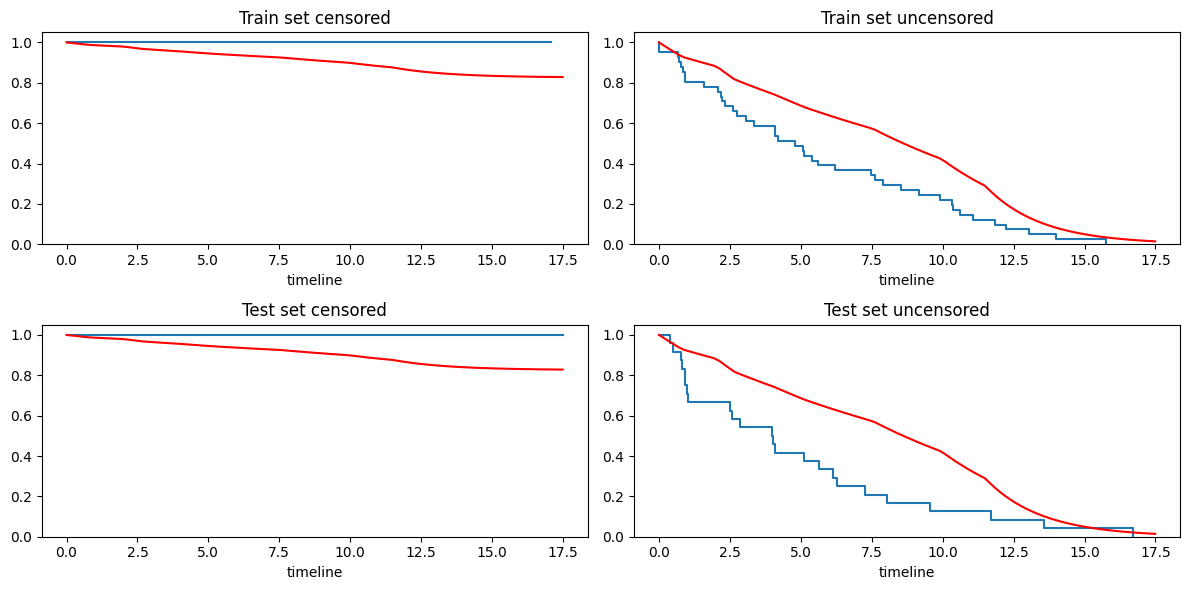

In [9]:
plot_censored_susceptible( poisson_simple_results )

## Grad-CAM structure

For the next implementations, it will be interest to use the Grad-CAM method to assess, at some extent, how the brain images are "seen" by the models themselves. We expect that the model will mostly "look at" the brain structure to find the desirable patterns intrinsic to Alzheimer's Disease (AD)

In [10]:
import cv2

def get_last_conv_layer_index(model):
    conv_indices = []
    for i, layer in enumerate(model.layers):
        if(hasattr(layer, "convolution_op")):
            conv_indices.append(i)
    return conv_indices[-1]

def generate_gradcam(model, img):
    i_last_conv = get_last_conv_layer_index(model)
    img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)
    x = model.layers[0](img_tensor)
    with tf.GradientTape() as tape:
        for i in range(1, len(model.layers)):
            # If we are at the last convolution layer, get its output and save it in a separate variable
            if(i == i_last_conv):
                last_conv_out = x = model.layers[i](x)
                tape.watch(last_conv_out)
            # The next layer output is based on the last convolutional layer output
            elif(i == (i_last_conv + 1)):
                x = model.layers[i](last_conv_out)
            # All the other layers are simply applications of each layer
            else:
                x = model.layers[i](x)
        # Get the last output of the last layer, associated to the cure probability
        target_score = x[0,-1]

    grads = tape.gradient(target_score, last_conv_out)

    # Global Average Pooling of the gradients to get the weight of each feature map
    pooled_grads = tf.reduce_mean(grads, axis = (0, 1, 2))

    # Multiply the feature maps by their gradient weights
    last_conv_out = last_conv_out[0] # Drop the batch dimension
    heatmap = last_conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU (we only care about pixels that had a *positive* influence on the prediction)
    heatmap = tf.nn.relu(heatmap)

    # Normalize the heatmap to be between 0 and 1
    heatmap_max = tf.math.reduce_max(heatmap)
    if heatmap_max != 0:
        heatmap = heatmap / heatmap_max

    return heatmap.numpy()

def gradcam_img(model, img):
    heatmap = generate_gradcam(model, img)
    original_image = img[0, :, :, 0]
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    return heatmap_resized

def plot_gradcam(model, img):
    """
        Overlays the Grad-CAM heatmap onto the original MRI slice.
    """
    # Get the Grad-CAM heatmap
    heatmap = generate_gradcam(model, img)
    
    # Extract the original 2D image (dropping batch and channel dims)
    original_image = img[0, :, :, 0]
    
    # Resize heatmap to match the original image size -> OpenCV format (width, height)
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    
    # Convert heatmap to RGB format for visualization
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Convert original image to RGB
    original_img_norm = np.uint8(255 * (original_image / np.max(original_image)))
    original_colored = cv2.cvtColor(original_img_norm, cv2.COLOR_GRAY2RGB)
    
    # Blend them together (0.6 opacity for MRI, 0.4 for heatmap)
    superimposed_img = cv2.addWeighted(original_colored, 0.6, heatmap_colored, 0.4, 0)
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(original_image, cmap='gray')
    ax[0].set_title("Original MRI Slice")
    ax[0].axis('off')
    
    ax[1].imshow(heatmap_resized, cmap='jet')
    ax[1].set_title("Raw Grad-CAM")
    ax[1].axis('off')
    
    ax[2].imshow(superimposed_img)
    ax[2].set_title("Overlay")
    ax[2].axis('off')
    
    plt.show()

## Neural network architecture

Here, we define the overall neural network structure we will be considering for the models.

We split it into two different implementations: for the first model, we only assume the cure probability of the patients to be the output of the neural network, while the $\alpha$ parameters from the baseline piecewise exponential distribution are global constants. For that reason, the neural network will have a single output value. For the second application, we consider that both the baseline distribution's parameters and the cure probability are directly modeled by the convolutional neural network. That implementation is very flexbile and we expect it to be the winning model above the other two approaches.

Apart from testing the single nature of the models, later we expand the results by fitting the same structures with alternative latent counting distributions from the Modified Power Series (MPS) family. By doing that, we aim to verify whether this dataset suggests alternative properties for the distribution of the number of possible latent causes in AD, such as its over- or under-dispersion, by choosing distributions other than the Poisson, for example.

In [11]:
def build_neural_network_structure(n_outputs):
    """
        Builds our rigid defined neural network structure where the number of output parameters is specified manually.
        That allows us to use this same function to call the different model architectures we propose here.
    """
    def neural_network(model, seed = None):
        initializer = initializers.GlorotNormal(seed = seed)
        
        model.convolution1 = keras.layers.Conv2D(filters = 4, kernel_size = [7,7], padding = "same", activation = tf.nn.leaky_relu,
                                                kernel_initializer = initializer, dtype = tf.float32)
        model.pooling1 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
        
        model.convolution2 = keras.layers.Conv2D(filters = 8, kernel_size = [5,5], padding = "same", activation = tf.nn.leaky_relu,
                                                kernel_initializer = initializer, dtype = tf.float32)
        model.pooling2 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
        
        model.convolution3 = keras.layers.Conv2D(filters = 16, kernel_size = [5,5], padding = "same", activation = tf.nn.leaky_relu,
                                                kernel_initializer = initializer, dtype = tf.float32)
        model.pooling3 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
        model.convolution4 = keras.layers.Conv2D(filters = 32, kernel_size = [3,3], padding = "same", activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.pooling4 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
        model.convolution5 = keras.layers.Conv2D(filters = 64, kernel_size = [3,3], padding = "same", activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.pooling5 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
        
        model.flatten = keras.layers.Reshape(target_shape=(-1,))
        model.dense1 = keras.layers.Dense(units = 128, activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.dense2 = keras.layers.Dense(units = 4, activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.dense3 = keras.layers.Dense(units = n_outputs, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = False)
        
    def neural_network_call(model, x_input, training = False):
        x = model.convolution1(x_input)
        x = model.pooling1(x)
        x = model.convolution2(x)
        x = model.pooling2(x)
        x = model.convolution3(x)
        x = model.pooling3(x)
        x = model.convolution4(x)
        x = model.pooling4(x)
        x = model.convolution5(x)
        x = model.pooling5(x)
        x = model.flatten(x)
        x = model.dense1(x)
        x = model.dense2(x)
        x = model.dense3(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.convolution1(x_input)
        x = model.pooling1(x)
        x = model.convolution2(x)
        x = model.pooling2(x)
        x = model.convolution3(x)
        x = model.pooling3(x)
        x = model.convolution4(x)
        x = model.pooling4(x)
        x = model.convolution5(x)
        x = model.pooling5(x)
        x = model.flatten(x)
        x = model.dense1(x)
        x = model.dense2(x)
        return x

    return neural_network, neural_network_call, neural_network_call_nolast

### Convolutional neural network - global base parameters

First, we will consider the standard promotion time cure model proposed by Xie & Yu (2021). For that, we consider the Poisson distribution for the number of latent causes.

For now we will consider the Poisson distribution. We will only expand the alternative MPS distributions later on this notebook.

In [12]:
poisson_spec = mpscr.MPSPoisson()
n_cuts = 8
pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = n_cuts)

# The number of parameters is given by the number of cuts in the piecewise exponential plus one extra parameter
# The final parameter is for the cure probability itself.
flexible_neural_network, flexible_neural_network_call, flexible_neural_network_call_nolast = \
build_neural_network_structure(1)

# MPScr model with global parameters for the base distribution (piecewise exponential, in this case)
poisson_medium_model = mpscr.build_medium_mpscr_model(y_train, delta_train, x_train.shape[1:], poisson_spec, pwexp_spec,
                                                      neural_network = flexible_neural_network, neural_network_call = flexible_neural_network_call,
                                                      neural_network_call_nolast = flexible_neural_network_call_nolast,
                                                      seed = 10)

keras.Model.summary(poisson_medium_model)

Model: "model_nn_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 140, 180, 4)    │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 70, 90, 8)      │           808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 35, 45, 16)     │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 22, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 11, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,857 (749.44 KB)

 Trainable params: 191,857 (749.44 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
data_train = [y_train, delta_train]
data_test = [y_test, delta_test]

n_cuts = 8
poisson_spec = mpscr.MPSPoisson()
pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = n_cuts)

medium_neural_network, medium_neural_network_call, medium_neural_network_call_nolast = \
build_neural_network_structure(1)

with tf.device("/GPU:0"):
    poisson_medium_model = mpscr.build_medium_mpscr_model(y_train, delta_train, x_train.shape[1:], poisson_spec, pwexp_spec,
                                                            neural_network = medium_neural_network, neural_network_call = medium_neural_network_call,
                                                            neural_network_call_nolast = medium_neural_network_call_nolast,
                                                            seed = 10)
    poisson_medium_model.train_model(epochs = 5000, x = x_train, data = data_train,
                                     shuffle = True,
                                     get_covariances = True,
                                     validation = True, val_prop = 0.2, force_training_validation = False,
                                     optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                     optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                                     fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                     early_stopping = True, early_stopping_patience = 50,
                                     early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                                     reduce_lr = True, reduce_lr_warmup = 0,
                                     reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                                     reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                     fine_tune = True,
                                     finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                                     finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                                     finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                     finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                                     finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                     deterministic = True,
                                     verbose = True, print_freq = 1)
    
    poisson_medium_results = poisson_medium_model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...


I0000 00:00:1784830377.090535   17135 cuda_dnn.cc:529] Loaded cuDNN version 92500
Could not load symbol cuStreamGetGreenCtx. Error: /lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuStreamGetGreenCtx


Optimizing... Epoch: [ 635 / 5000 ]  | Avg. Train NLL:  0.314741254 | Avg. Validation NLL:  0.395776838 | Best Avg. Validation NLL:  0.39105013 | Speed:  0.170842126  epoch/s    | Elapsed Time:  108.484749  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 292 / 5000 ]  | Avg. Train NLL:  0.31545487 | Best Avg. Train NLL:  0.31545487 | Avg. Validation NLL:  0.379913449 | Speed:  0.0720204487  epoch/s    | Elapsed Time:  21.0299721  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.


I0000 00:00:1784830511.309766   17036 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x5869eaf7d000


Done.
Optimization finished in 138.432 seconds.


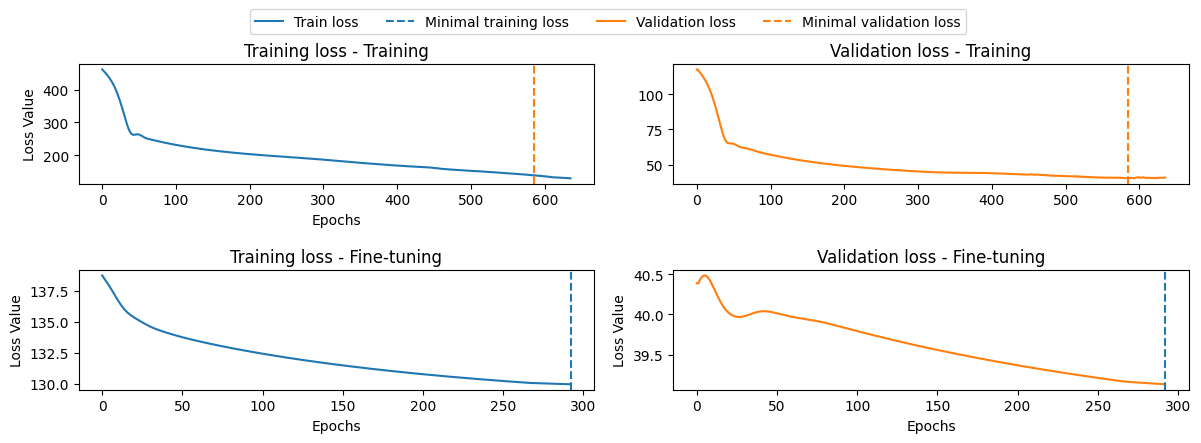

In [14]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,4))
utils.plot_model_convergence( poisson_medium_model, ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1] )

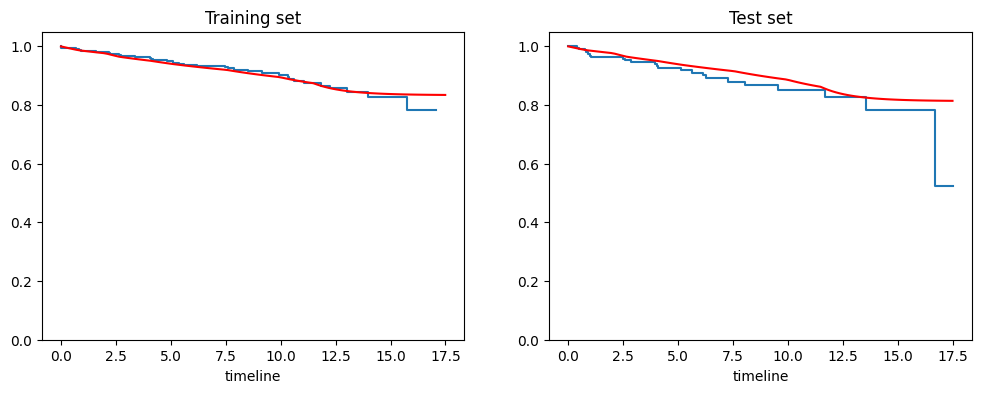

In [63]:
ts_grid = poisson_medium_results["ts_grid"]
p_train = poisson_medium_results["p_train"]
p_test = poisson_medium_results["p_test"]
S_ts_train = poisson_medium_results["S_ts_train"]
S_ts_test = poisson_medium_results["S_ts_test"]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.average_kaplan_meier_train_test(ts_grid,
                                      S_ts_train, S_ts_test,
                                      y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1])

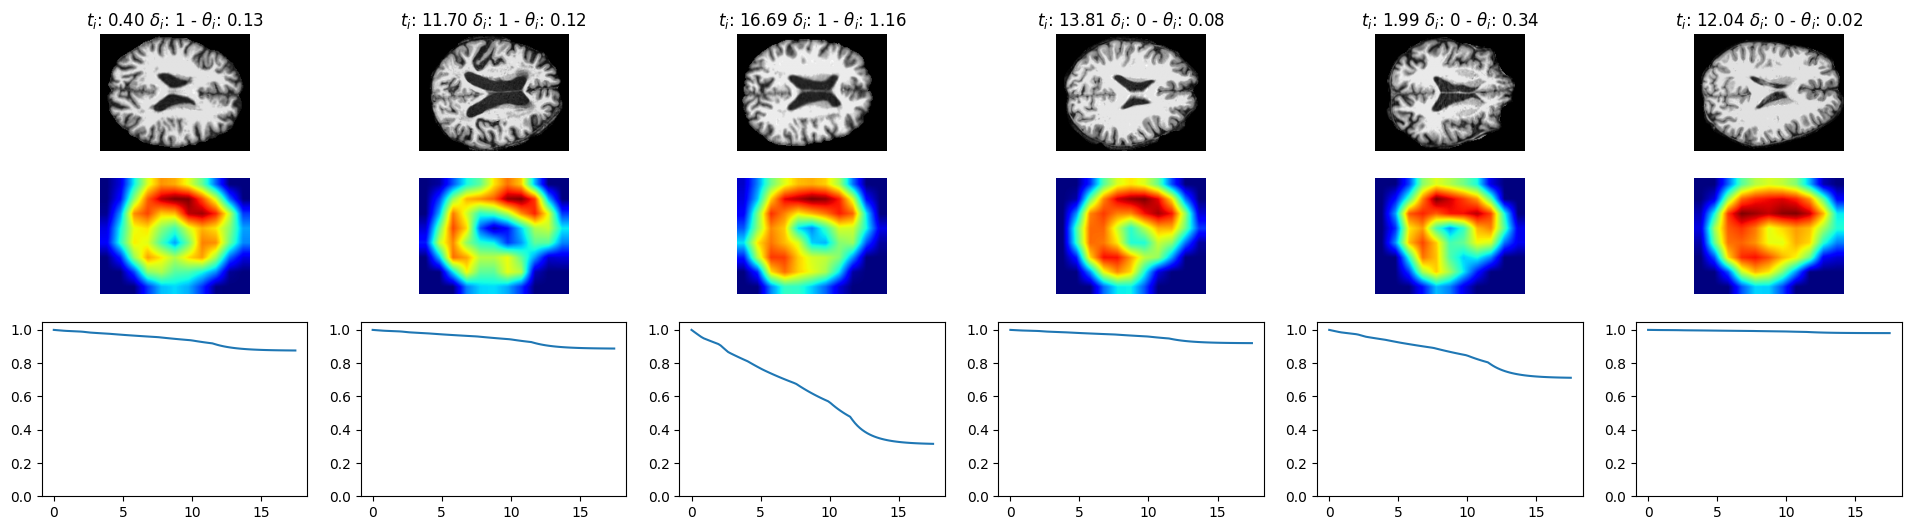

In [16]:
# np.random.seed(3)
np.random.seed(15)

# Select five patients from the test set who happened to be diagnosed with AD
susceptible_idx = np.random.choice(np.arange(x_test.shape[0]), size = 6, p = delta_test / np.sum(delta_test))
# Sample 5 patients from the test set whose lifetimes are censored
idx = np.random.choice(np.arange(x_test.shape[0]), size = 6, p = (1-delta_test) / np.sum(1-delta_test))

idx[:3] = susceptible_idx[:3]

fig, ax = plt.subplots(nrows = 3, ncols = 6, figsize = (24,6),
                       gridspec_kw = {
                           'height_ratios': [1,1,1.5],
                           'width_ratios': [1,1,1,1,1,1]
                       })
    
t = np.linspace(0.01, np.max(y_train))

for i in range(6):
    ax[0,i].imshow( x_test[idx[i]], cmap = "gray" )
    ax[0,i].set_title(r"$t_i$: {:.2f} $\delta_i$: {} - $\theta_i$: {:.2f}".format(y_test.iloc[idx[i]], delta_test.iloc[idx[i]], poisson_medium_results["theta_test"][idx[i],0]))
    ax[0,i].set_axis_off()

    gradcam = gradcam_img(poisson_medium_model, x_test[idx[i]:(idx[i]+1)] )
    ax[1,i].imshow( gradcam, cmap = "jet" )
    ax[1,i].set_axis_off()

    ax[2,i].plot( poisson_medium_results["ts_grid"].flatten(), poisson_medium_results["S_ts_test"][idx[i], :] )
    ax[2,i].set_ylim(0, 1.05)

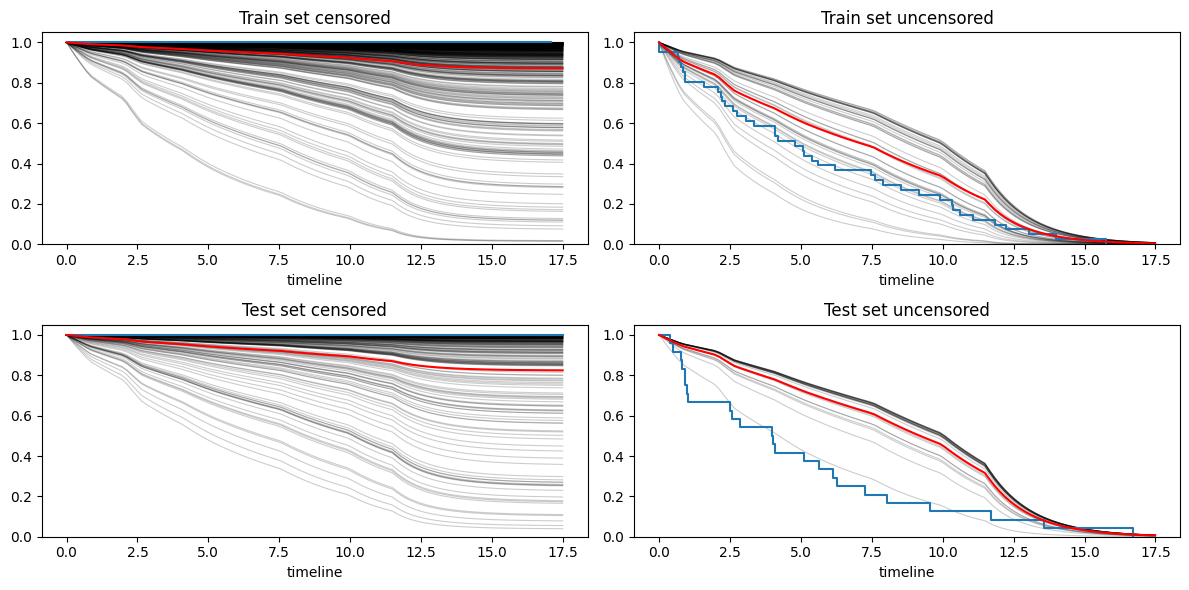

In [17]:
plot_censored_susceptible( poisson_medium_results )

### Convolutional neural network - flexible base parameters

In [18]:
poisson_spec = mpscr.MPSPoisson()
n_cuts = 8
pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = n_cuts)

# The number of parameters is given by the number of cuts in the piecewise exponential plus one extra parameter
# The final parameter is for the cure probability itself.
flexible_neural_network, flexible_neural_network_call, flexible_neural_network_call_nolast = \
build_neural_network_structure(n_cuts+2)

# MPScr model with global parameters for the base distribution (piecewise exponential, in this case)
poisson_flexible_model = mpscr.build_flexible_mpscr_model(y_train, delta_train, x_train.shape[1:], poisson_spec, pwexp_spec,
                                                          neural_network = flexible_neural_network, neural_network_call = flexible_neural_network_call,
                                                          neural_network_call_nolast = flexible_neural_network_call_nolast,
                                                          seed = 10)

keras.Model.summary(poisson_flexible_model)

Model: "model_nn_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 140, 180, 4)    │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 70, 90, 8)      │           808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 35, 45, 16)     │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 17, 22, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 11, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │            40 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,884 (749.55 KB)

 Trainable params: 191,884 (749.55 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
data_train = [y_train, delta_train]
data_test = [y_test, delta_test]

n_cuts = 8
poisson_spec = mpscr.MPSPoisson()
pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = n_cuts)

flexible_neural_network, flexible_neural_network_call, flexible_neural_network_call_nolast = \
build_neural_network_structure(n_cuts+2)

with tf.device("/GPU:0"):
    poisson_flexible_model = mpscr.build_flexible_mpscr_model(y_train, delta_train, x_train.shape[1:], poisson_spec, pwexp_spec,
                                                     neural_network = flexible_neural_network, neural_network_call = flexible_neural_network_call,
                                                     neural_network_call_nolast = flexible_neural_network_call_nolast,
                                                     seed = 10)
    poisson_flexible_model.train_model(epochs = 5000, x = x_train, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
    
    poisson_flexible_results = poisson_flexible_model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 404 / 5000 ]  | Avg. Train NLL:  0.417308 | Avg. Validation NLL:  0.563781321 | Best Avg. Validation NLL:  0.55012387 | Speed:  0.165913388  epoch/s    | Elapsed Time:  67.0290146  s       
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 757 / 5000 ]  | Avg. Train NLL:  0.272342771 | Best Avg. Train NLL:  0.272342771 | Avg. Validation NLL:  0.453618407 | Speed:  0.07083866  epoch/s    | Elapsed Time:  53.6248627  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 128.483 seconds.


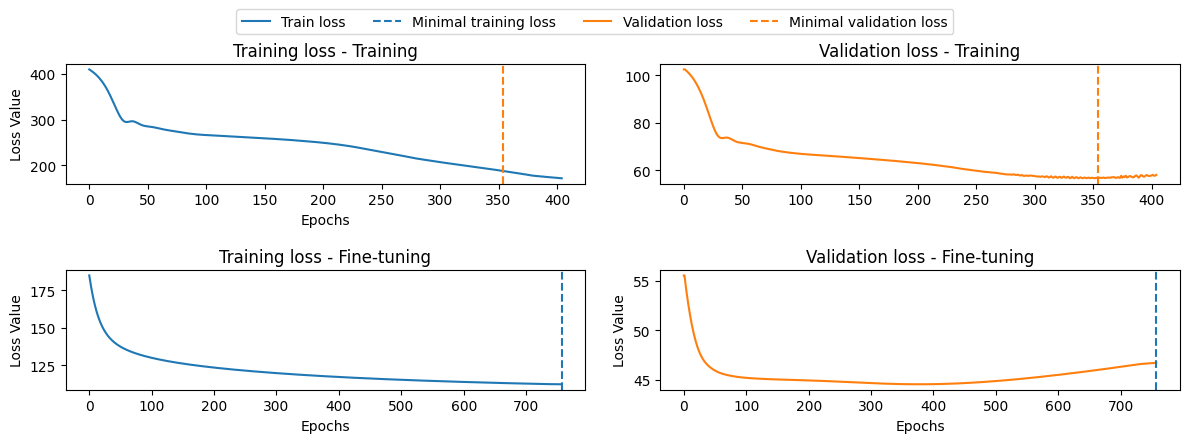

In [20]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,4))

utils.plot_model_convergence( poisson_flexible_model, ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1] )

It seems that the neural network was not able to properly learn the convolutional features of the data.

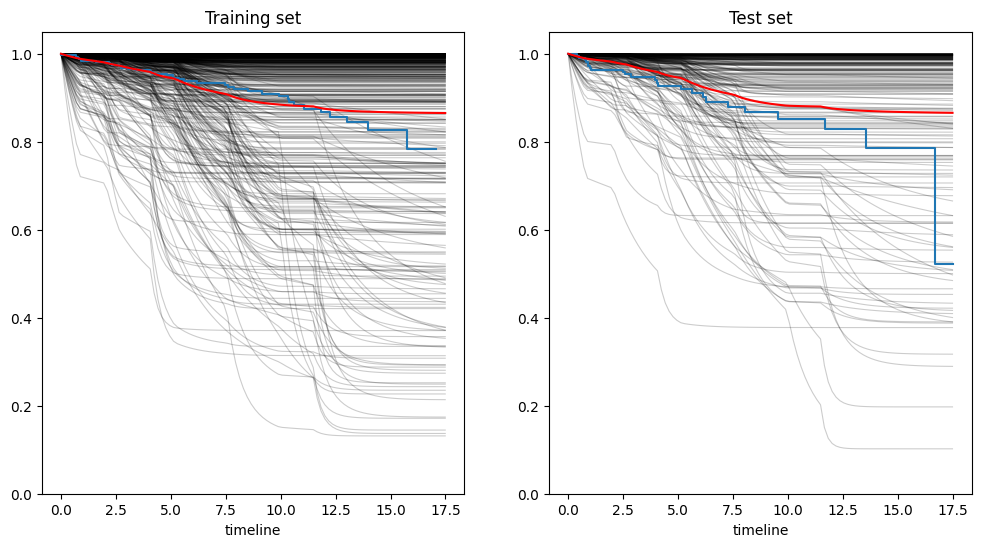

In [56]:
ts_grid = poisson_flexible_results["ts_grid"]
p_train = poisson_flexible_results["p_train"]
p_test = poisson_flexible_results["p_test"]
S_ts_train = poisson_flexible_results["S_ts_train"]
S_ts_test = poisson_flexible_results["S_ts_test"]

# Should we consider these curves for the Kaplan-Meier assessment? Both plots look fine anyway!
# S_ts_train[delta_train == 1,:] = (S_ts_train[delta_train == 1,:] - p_train[delta_train == 1]) / (1 - p_train[delta_train == 1])
# S_ts_test[delta_test == 1,:] = (S_ts_test[delta_test == 1,:] - p_test[delta_test == 1]) / (1 - p_test[delta_test == 1])

utils.average_kaplan_meier_train_test(ts_grid,
                                      S_ts_train, S_ts_test,
                                      y_train, delta_train, y_test, delta_test, show_individual = True)

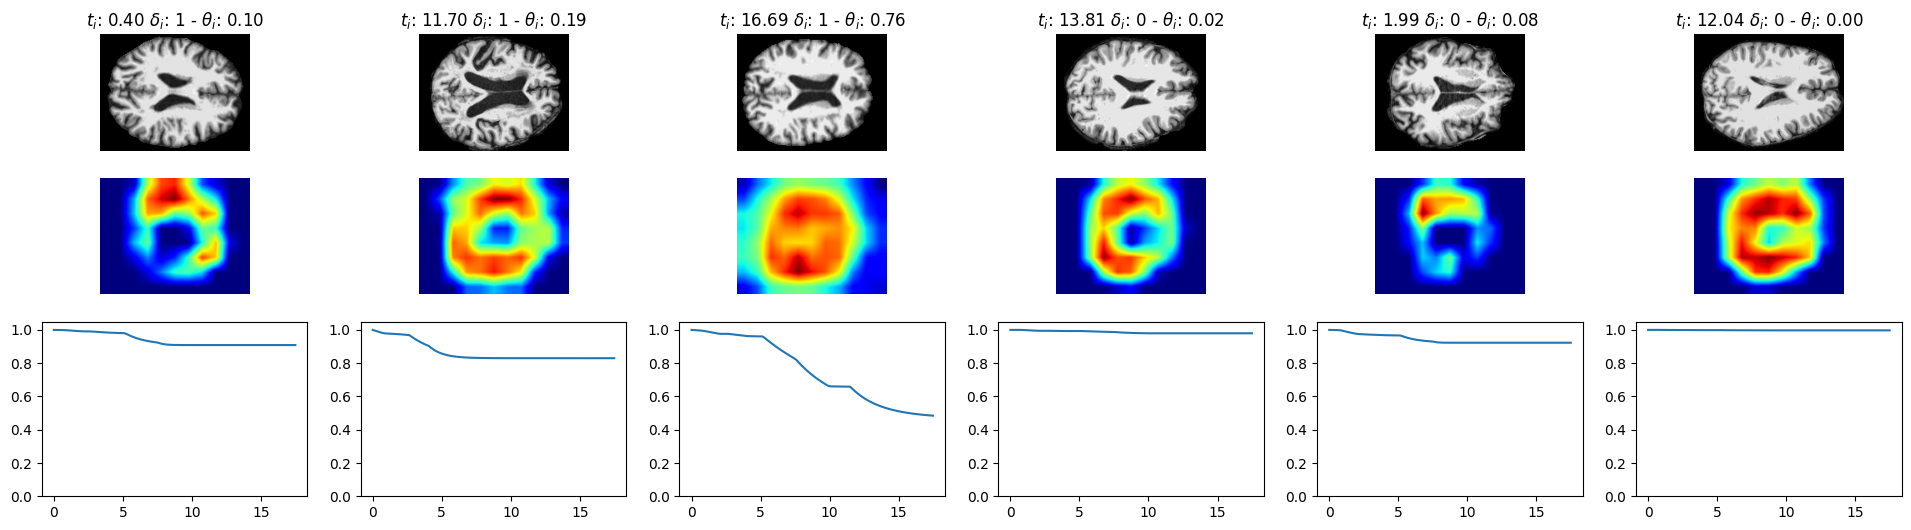

In [22]:
# np.random.seed(3)
np.random.seed(15)

# Select five patients from the test set who happened to be diagnosed with AD
susceptible_idx = np.random.choice(np.arange(x_test.shape[0]), size = 6, p = delta_test / np.sum(delta_test))
# Sample 5 patients from the test set whose lifetimes are censored
idx = np.random.choice(np.arange(x_test.shape[0]), size = 6, p = (1-delta_test) / np.sum(1-delta_test))

idx[:3] = susceptible_idx[:3]

fig, ax = plt.subplots(nrows = 3, ncols = 6, figsize = (24,6),
                       gridspec_kw = {
                           'height_ratios': [1,1,1.5],
                           'width_ratios': [1,1,1,1,1,1]
                       })
    
t = np.linspace(0.01, np.max(y_train))

for i in range(6):
    ax[0,i].imshow( x_test[idx[i]], cmap = "gray" )
    ax[0,i].set_title(r"$t_i$: {:.2f} $\delta_i$: {} - $\theta_i$: {:.2f}".format(y_test.iloc[idx[i]], delta_test.iloc[idx[i]], poisson_flexible_results["theta_test"][idx[i],0]))
    ax[0,i].set_axis_off()

    gradcam = gradcam_img(poisson_flexible_model, x_test[idx[i]:(idx[i]+1)] )
    ax[1,i].imshow( gradcam, cmap = "jet" )
    ax[1,i].set_axis_off()

    ax[2,i].plot( poisson_flexible_results["ts_grid"].flatten(), poisson_flexible_results["S_ts_test"][idx[i], :] )
    ax[2,i].set_ylim(0, 1.05)

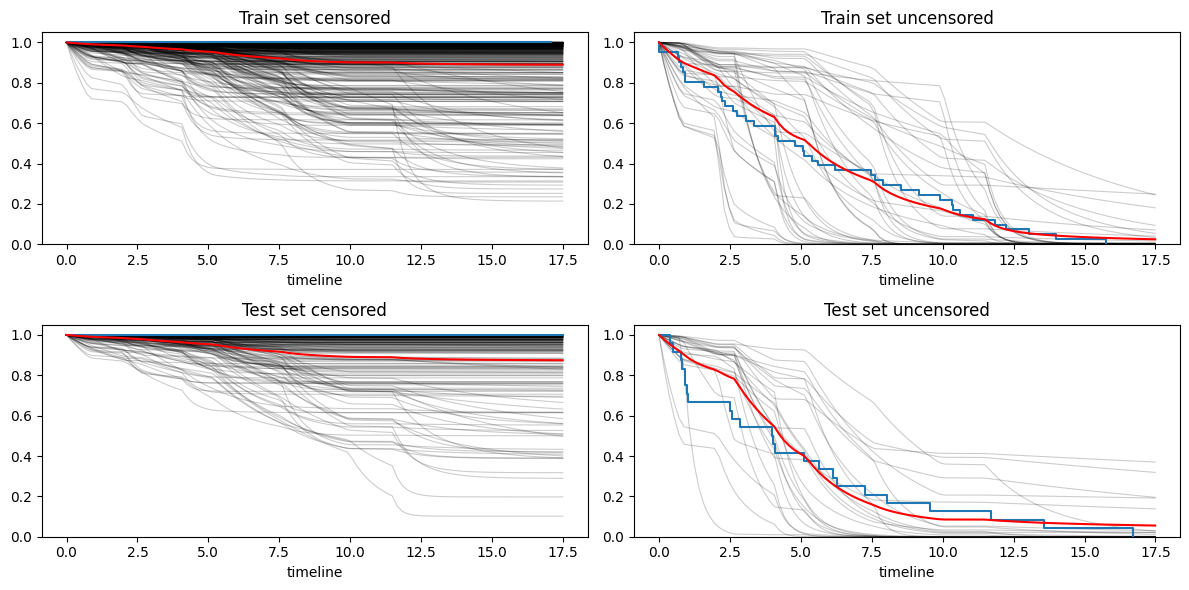

In [23]:
plot_censored_susceptible( poisson_flexible_results )

## Models alternative to the Poisson

The function below merges all model types presented above into a single function call. That way, we can seamlesly call very different model structures while keeping the same overall results pattern for easy comparison between all models. We are interested both in selecting the best model structure and the correct distribution for the latent causes according to the data.

In [24]:
def fit_model(dist, model_type, y_train, delta_train, x_train, y_test, delta_test, x_test, fixed_q = 0.0, epochs = 5000, n_cuts = 8):
    pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = n_cuts)

    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "geometric"):
        model_spec = mpscr.MPSNegBinomial(1.0)
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    elif(dist == "rgp"):
        model_spec = mpscr.MPSRGP()
    else:
        raise Exception("Please, provide a valid subfamily name.")

    data_train = [y_train, delta_train]
    if(model_type == "simple"):
        with tf.device("/CPU:0"):
            model = mpscr.build_simple_mpscr_model(y_train, delta_train, model_spec, pwexp_spec, seed = 10 )
            model.train_model(epochs = 5000, x = None, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
            model_results = model.get_survival_cure(y_train, delta_train, y_test, delta_test, ngrid = 100)
    elif(model_type == "medium"):
        medium_neural_network, medium_neural_network_call, medium_neural_network_call_nolast = build_neural_network_structure(1)
        with tf.device("/GPU:0"):
            model = mpscr.build_medium_mpscr_model(y_train, delta_train, x_train.shape[1:], model_spec, pwexp_spec,
                                                   neural_network = medium_neural_network, neural_network_call = medium_neural_network_call,
                                                   neural_network_call_nolast = medium_neural_network_call_nolast,
                                                   seed = 10)
            model.train_model(epochs = 5000, x = x_train, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
            model_results = model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)
    elif(model_type == "flexible"):
        flexible_neural_network, flexible_neural_network_call, flexible_neural_network_call_nolast = build_neural_network_structure(n_cuts+2)
        with tf.device("/GPU:0"):
            model = mpscr.build_flexible_mpscr_model(y_train, delta_train, x_train.shape[1:], model_spec, pwexp_spec,
                                                     neural_network = flexible_neural_network, neural_network_call = flexible_neural_network_call,
                                                     neural_network_call_nolast = flexible_neural_network_call_nolast,
                                                     seed = 10)
            model.train_model(epochs = 5000, x = x_train, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
            model_results = model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)
    else:
        print("Please, provide a valid model type (simple, medium, flexible).")
    
    return model, model_results

### Simple models

In [25]:
bin5_simple_model, bin5_simple_results = fit_model("bin", "simple", y_train, delta_train, x_train, y_test, delta_test, x_test, fixed_q = 5.0, n_cuts = 8)
negbin_simple_model, negbin_simple_results = fit_model("negbin", "simple", y_train, delta_train, x_train, y_test, delta_test, x_test, n_cuts = 8)
log_simple_model, log_simple_results = fit_model("log", "simple", y_train, delta_train, x_train, y_test, delta_test, x_test, n_cuts = 8)
rgp_simple_model, rgp_simple_results = fit_model("rgp", "simple", y_train, delta_train, x_train, y_test, delta_test, x_test, n_cuts = 8)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1186 / 5000 ]  | Avg. Train NLL:  0.442841947 | Avg. Validation NLL:  0.38987878 | Best Avg. Validation NLL:  0.38987878 | Speed:  0.00174468581  epoch/s    | Elapsed Time:  2.06919742  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 5.104 seconds.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1196 / 5000 ]  | Avg. Train NLL:  0.442851037 | Avg. Validation NLL:  0.390046716 | Best Avg. Validation NLL:  0.390046716 | Speed:  0.00202421797  epoch/s    | Elapsed Time:  2.42096472  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 6.439 seconds.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1240 / 5000 ]  | Avg. Train NLL:  0.442886829 | Avg. Validation NLL:  0.390595257 | Best Avg. V

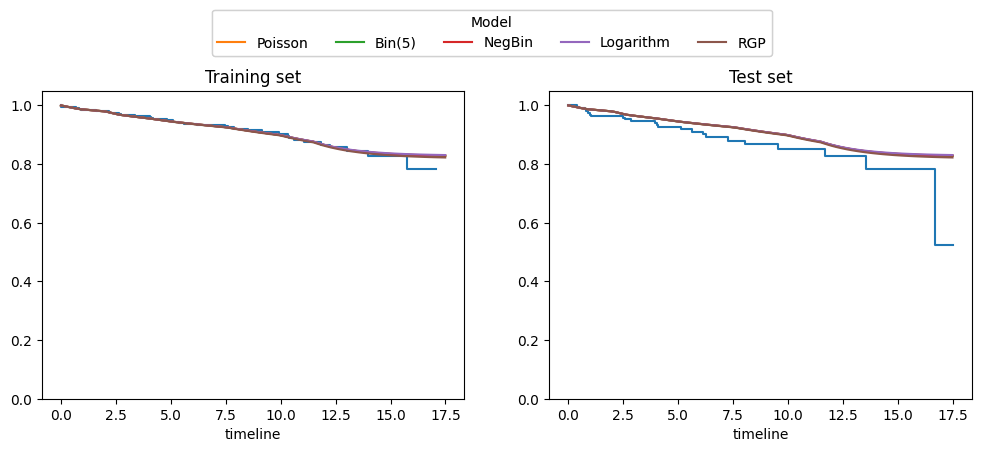

In [27]:
simple_model_results = [poisson_simple_results, bin5_simple_results, negbin_simple_results, log_simple_results, rgp_simple_results]
model_names = ["Poisson", "Bin(5)", "NegBin", "Logarithm", "RGP"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

group_handles = []

for i, result in enumerate(simple_model_results):
    plot_km = False
    if(i == 0):
        plot_km = True
    ts_grid = result["ts_grid"]
    p_train = result["p_train"]
    p_test = result["p_test"]
    S_ts_train = result["S_ts_train"]
    S_ts_test = result["S_ts_test"]
    utils.average_kaplan_meier_train_test(ts_grid,
                                          S_ts_train, S_ts_test,
                                          y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1],
                                          color = colors[i+1], plot_km = plot_km)
    group_handles.append( Line2D([0], [0], color = colors[i+1], linestyle = '-', label = model_names[i]) )

legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.1),
    title = "Model",
    ncol = len(simple_model_results)
)

fig.add_artist(legend1)

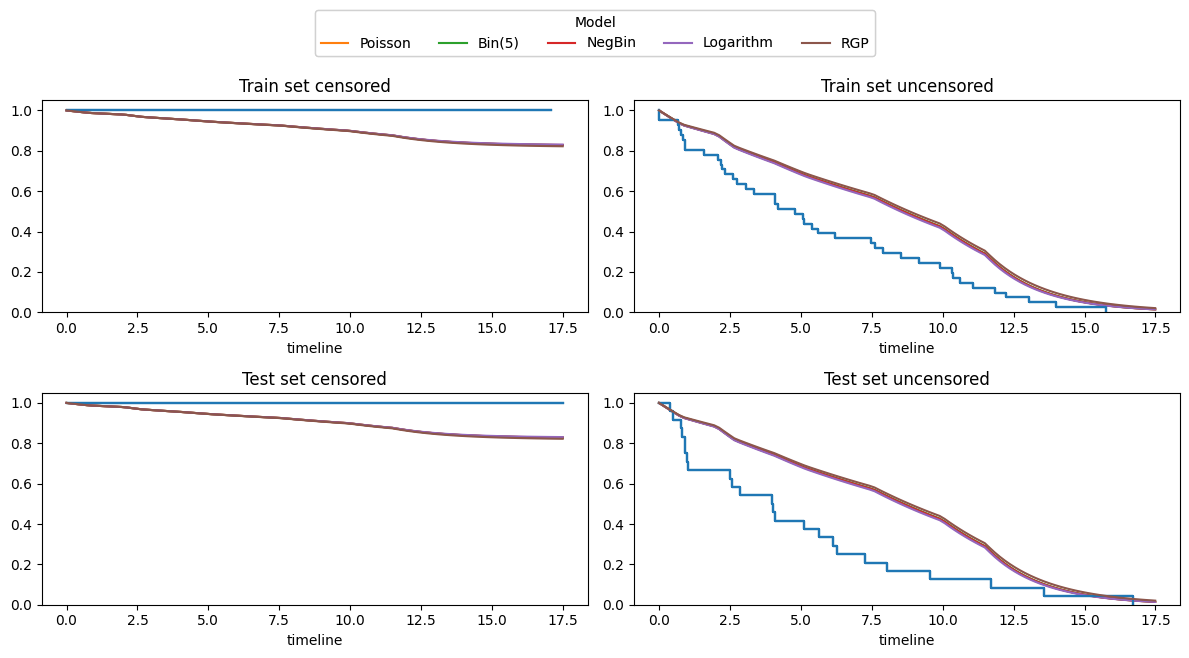

In [29]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,6))

group_handles = []

for i, result in enumerate(simple_model_results):
    plot_km = False
    if(i == 0):
        plot_km = True
    plot_censored_susceptible( result, color = colors[i+1], ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1], plot_km = plot_km )
    group_handles.append( Line2D([0], [0], color = colors[i+1], linestyle = '-', label = model_names[i]) )

# Add the first legend (Groups) - Anchored to the top left
legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.1), # Centered horizontally and pushed just above the figure
    title = "Model",
    ncol = len(simple_model_results) # Dynamically sets columns to match the number of iterations
)

fig.add_artist(legend1)
fig.tight_layout()

### Global base parameter results

In [30]:
bin5_medium_model, bin5_medium_results = fit_model("bin", "medium", y_train, delta_train, x_train, y_test, delta_test, x_test, fixed_q = 5.0, n_cuts = 8)
negbin_medium_model, negbin_medium_results = fit_model("negbin", "medium", y_train, delta_train, x_train, y_test, delta_test, x_test, n_cuts = 8)
log_medium_model, log_medium_results = fit_model("log", "medium", y_train, delta_train, x_train, y_test, delta_test, x_test, n_cuts = 8)
rgp_medium_model, rgp_medium_results = fit_model("rgp", "medium", y_train, delta_train, x_train, y_test, delta_test, x_test, n_cuts = 8)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 613 / 5000 ]  | Avg. Train NLL:  0.323889494 | Avg. Validation NLL:  0.395032525 | Best Avg. Validation NLL:  0.392309725 | Speed:  0.166820616  epoch/s    | Elapsed Time:  102.261032  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 280 / 5000 ]  | Avg. Train NLL:  0.327350885 | Best Avg. Train NLL:  0.327350885 | Avg. Validation NLL:  0.380668074 | Speed:  0.0697107241  epoch/s    | Elapsed Time:  19.5190029  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 130.119 seconds.
GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
G

/home/natan/.pyenv/versions/3.10.17/lib/python3.10/site-packages/thetaflow/modelnn.py:2755: RuntimeWarning: Covariance matrix could not be computed because the log-likelihood Hessian is singular (or near singular).
The model may not be identified.

  warnings.warn(


Done.
Optimization finished in 138.778 seconds.
GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 555 / 5000 ]  | Avg. Train NLL:  0.291746557 | Avg. Validation NLL:  0.409484297 | Best Avg. Validation NLL:  0.395410091 | Speed:  0.171790704  epoch/s    | Elapsed Time:  95.3438416  s   
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 556 / 5000 ]  | Avg. Train NLL:  0.291606069 | Avg. Validation NLL:  0.408878475 | Best Avg. Validation NLL:  0.395410091 | Speed:  0.171851009  epoch/s    | Elapsed Time:  95.5491562  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 720 / 5000 ]  | Avg. Train NLL:  0.289122969 | Best Avg. Train NLL:  0.289122969 | Avg. Validation NLL:  0.386762351 | Speed:  0.0938013  epoch/s    | Elapsed Time:  67.5369339  s      
Converge

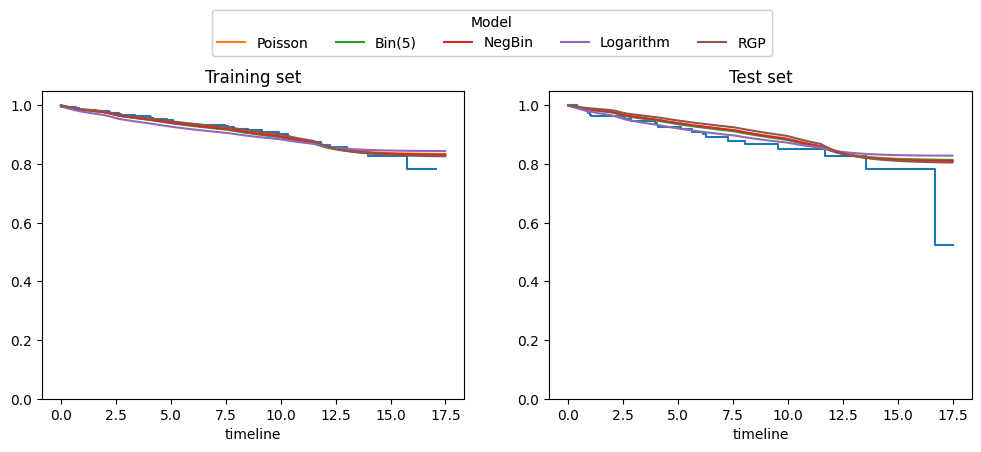

In [31]:
medium_model_results = [poisson_medium_results, bin5_medium_results, negbin_medium_results, log_medium_results, rgp_medium_results]
model_names = ["Poisson", "Bin(5)", "NegBin", "Logarithm", "RGP"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

group_handles = []

for i, result in enumerate(medium_model_results):
    plot_km = False
    if(i == 0):
        plot_km = True
    ts_grid = result["ts_grid"]
    p_train = result["p_train"]
    p_test = result["p_test"]
    S_ts_train = result["S_ts_train"]
    S_ts_test = result["S_ts_test"]
    utils.average_kaplan_meier_train_test(ts_grid,
                                          S_ts_train, S_ts_test,
                                          y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1],
                                          color = colors[i+1], plot_km = plot_km)
    group_handles.append( Line2D([0], [0], color = colors[i+1], linestyle = '-', label = model_names[i]) )

# Add the first legend (Groups) - Anchored to the top left
legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.1), # Centered horizontally and pushed just above the figure
    title = "Model",
    ncol = len(medium_model_results) # Dynamically sets columns to match the number of iterations
)

fig.add_artist(legend1)
plt.show()

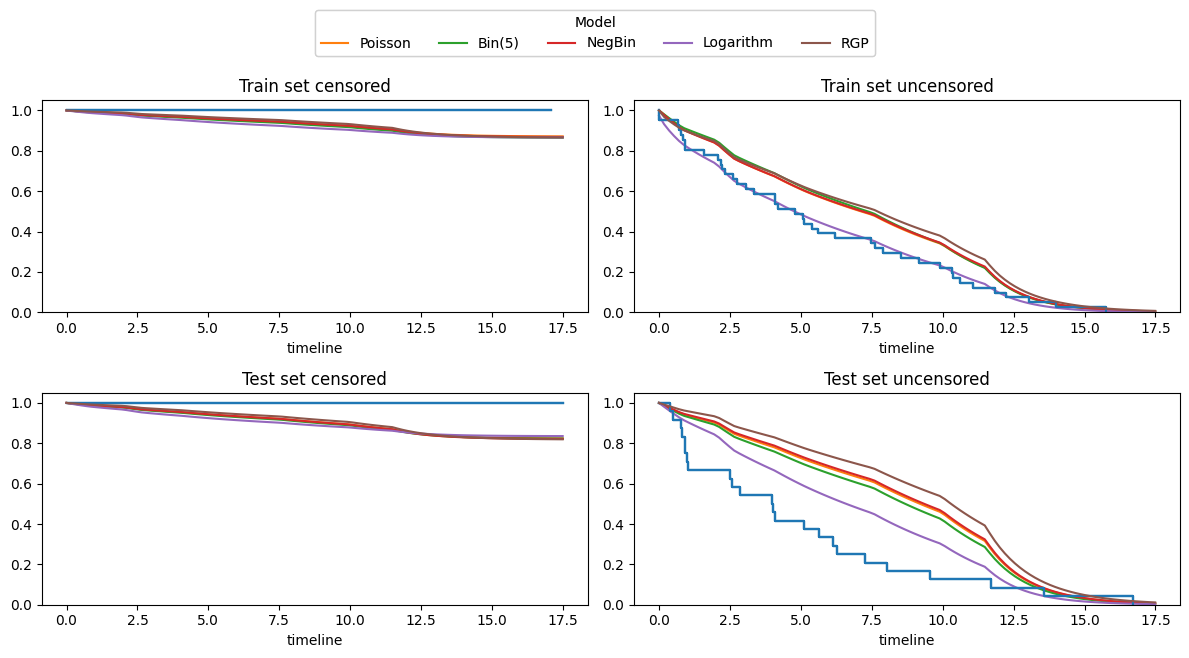

In [32]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,6))

group_handles = []

for i, result in enumerate(medium_model_results):
    plot_km = False
    if(i == 0):
        plot_km = True
    plot_censored_susceptible( result, color = colors[i+1], ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1], plot_km = plot_km, show_individual = False )
    group_handles.append( Line2D([0], [0], color = colors[i+1], linestyle = '-', label = model_names[i]) )

legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.1),
    title = "Model",
    ncol = len(medium_model_results)
)

fig.add_artist(legend1) 

# Prevent the top legends from being clipped off the final image
plt.tight_layout()

### Flexible base parameter results

In [33]:
bin5_flexible_model, bin5_flexible_results = fit_model("bin", "flexible", y_train, delta_train, x_train, y_test, delta_test, x_test, fixed_q = 5.0, n_cuts = 8)
negbin_flexible_model, negbin_flexible_results = fit_model("negbin", "flexible", y_train, delta_train, x_train, y_test, delta_test, x_test, n_cuts = 8)
log_flexible_model, log_flexible_results = fit_model("log", "flexible", y_train, delta_train, x_train, y_test, delta_test, x_test, n_cuts = 8)
rgp_flexible_model, rgp_flexible_results = fit_model("rgp", "flexible", y_train, delta_train, x_train, y_test, delta_test, x_test, n_cuts = 8)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 414 / 5000 ]  | Avg. Train NLL:  0.401462406 | Avg. Validation NLL:  0.578762233 | Best Avg. Validation NLL:  0.545347691 | Speed:  0.164135009  epoch/s    | Elapsed Time:  67.9519  s      
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 765 / 5000 ]  | Avg. Train NLL:  0.253477216 | Best Avg. Train NLL:  0.253477216 | Avg. Validation NLL:  0.526405513 | Speed:  0.0694286227  epoch/s    | Elapsed Time:  53.1129  s      
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 129.952 seconds.
GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
G

/home/natan/.pyenv/versions/3.10.17/lib/python3.10/site-packages/thetaflow/modelnn.py:2755: RuntimeWarning: Covariance matrix could not be computed because the log-likelihood Hessian is singular (or near singular).
The model may not be identified.

  warnings.warn(


Done.
Optimization finished in 125.734 seconds.


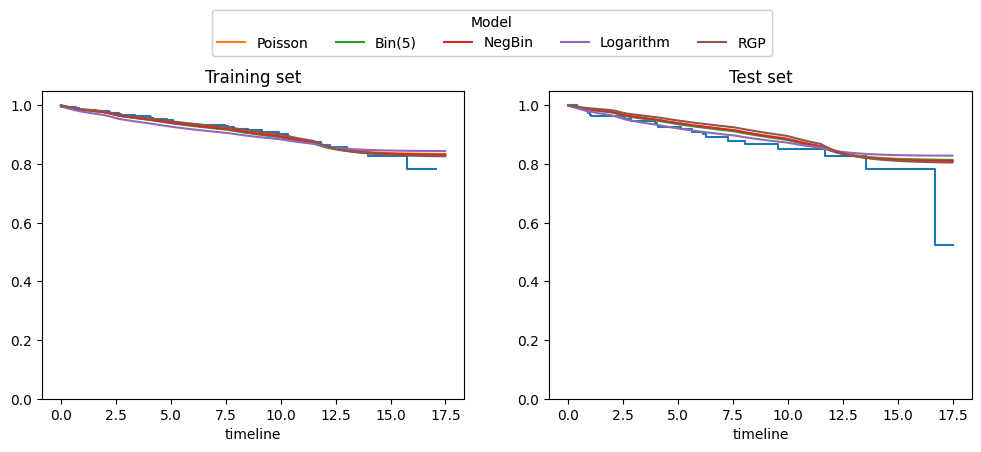

In [36]:
flexible_model_results = [poisson_flexible_results, bin5_flexible_results, negbin_flexible_results, log_flexible_results, rgp_flexible_results]
model_names = ["Poisson", "Bin(5)", "NegBin", "Logarithm", "RGP"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

group_handles = []

for i, result in enumerate(medium_model_results):
    plot_km = False
    if(i == 0):
        plot_km = True
    ts_grid = result["ts_grid"]
    p_train = result["p_train"]
    p_test = result["p_test"]
    S_ts_train = result["S_ts_train"]
    S_ts_test = result["S_ts_test"]
    utils.average_kaplan_meier_train_test(ts_grid,
                                          S_ts_train, S_ts_test,
                                          y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1],
                                          color = colors[i+1], plot_km = plot_km)
    group_handles.append( Line2D([0], [0], color = colors[i+1], linestyle = '-', label = model_names[i]) )

legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.1), # Centered horizontally and pushed just above the figure
    title = "Model",
    ncol = len(flexible_model_results) # Dynamically sets columns to match the number of iterations
)

fig.add_artist(legend1)
plt.show()

In [62]:
negbin_flexible_model.predict('q')

array([0.05351814], dtype=float32)

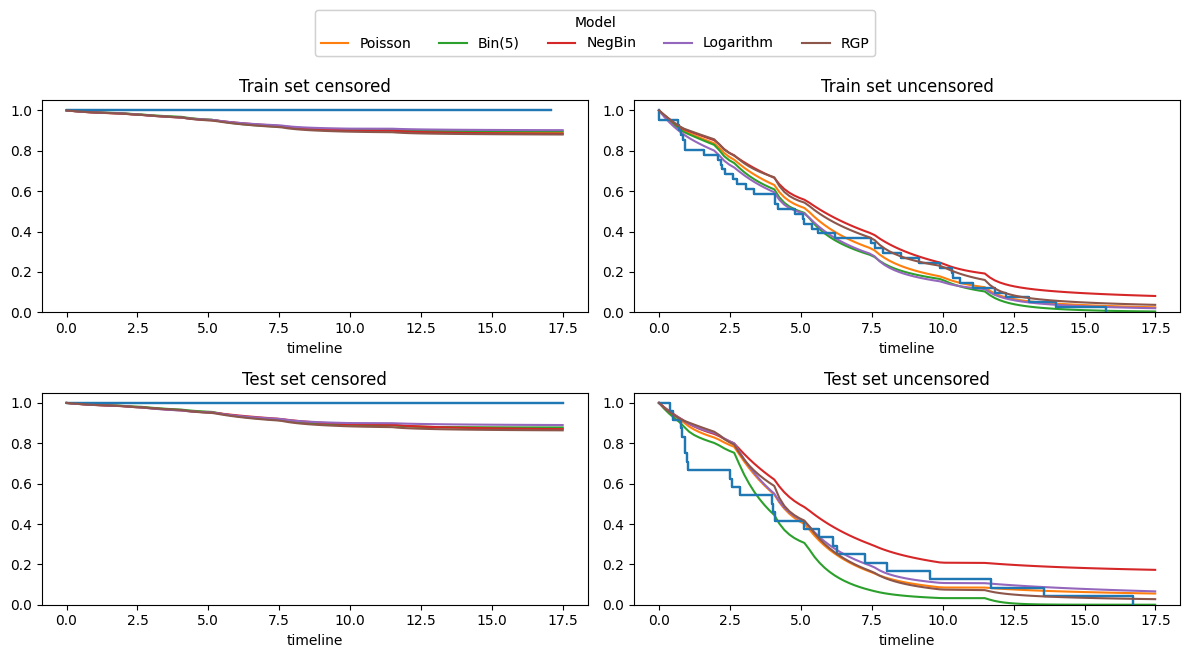

In [37]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,6))

group_handles = []

for i, result in enumerate(flexible_model_results):
    plot_km = False
    if(i == 0):
        plot_km = True
    plot_censored_susceptible( result, color = colors[i+1], ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1], plot_km = plot_km, show_individual = False )
    group_handles.append( Line2D([0], [0], color = colors[i+1], linestyle = '-', label = model_names[i]) )

legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.1),
    title = "Model",
    ncol = len(flexible_model_results)
)

fig.add_artist(legend1) 

# Prevent the top legends from being clipped off the final image
plt.tight_layout()

In [44]:
resid_poisson_simple_train = utils.compute_randomized_residuals_censoring( poisson_simple_results["S_train"], poisson_simple_results["delta_train"] )
resid_bin5_simple_train = utils.compute_randomized_residuals_censoring( bin5_simple_results["S_train"], bin5_simple_results["delta_train"] )
resid_negbi_simple_train = utils.compute_randomized_residuals_censoring( negbin_simple_results["S_train"], negbin_simple_results["delta_train"] )
resid_log_simple_train = utils.compute_randomized_residuals_censoring( log_simple_results["S_train"], log_simple_results["delta_train"] )
resid_rgp_simple_train = utils.compute_randomized_residuals_censoring( rgp_simple_results["S_train"], rgp_simple_results["delta_train"] )

resid_poisson_medium_train = utils.compute_randomized_residuals_censoring( poisson_medium_results["S_train"], poisson_medium_results["delta_train"] )
resid_bin5_medium_train = utils.compute_randomized_residuals_censoring( bin5_medium_results["S_train"], bin5_medium_results["delta_train"] )
resid_negbi_medium_train = utils.compute_randomized_residuals_censoring( negbin_medium_results["S_train"], negbin_medium_results["delta_train"] )
resid_log_medium_train = utils.compute_randomized_residuals_censoring( log_medium_results["S_train"], log_medium_results["delta_train"] )
resid_rgp_medium_train = utils.compute_randomized_residuals_censoring( rgp_medium_results["S_train"], rgp_medium_results["delta_train"] )

resid_poisson_flexible_train = utils.compute_randomized_residuals_censoring( poisson_flexible_results["S_train"], poisson_flexible_results["delta_train"] )
resid_bin5_flexible_train = utils.compute_randomized_residuals_censoring( bin5_flexible_results["S_train"], bin5_flexible_results["delta_train"] )
resid_negbi_flexible_train = utils.compute_randomized_residuals_censoring( negbin_flexible_results["S_train"], negbin_flexible_results["delta_train"] )
resid_log_flexible_train = utils.compute_randomized_residuals_censoring( log_flexible_results["S_train"], log_flexible_results["delta_train"] )
resid_rgp_flexible_train = utils.compute_randomized_residuals_censoring( rgp_flexible_results["S_train"], rgp_flexible_results["delta_train"] )

resid_poisson_simple_test = utils.compute_randomized_residuals_censoring( poisson_simple_results["S_test"], poisson_simple_results["delta_test"] )
resid_bin5_simple_test = utils.compute_randomized_residuals_censoring( bin5_simple_results["S_test"], bin5_simple_results["delta_test"] )
resid_negbi_simple_test = utils.compute_randomized_residuals_censoring( negbin_simple_results["S_test"], negbin_simple_results["delta_test"] )
resid_log_simple_test = utils.compute_randomized_residuals_censoring( log_simple_results["S_test"], log_simple_results["delta_test"] )
resid_rgp_simple_test = utils.compute_randomized_residuals_censoring( rgp_simple_results["S_test"], rgp_simple_results["delta_test"] )

resid_poisson_medium_test = utils.compute_randomized_residuals_censoring( poisson_medium_results["S_test"], poisson_medium_results["delta_test"] )
resid_bin5_medium_test = utils.compute_randomized_residuals_censoring( bin5_medium_results["S_test"], bin5_medium_results["delta_test"] )
resid_negbi_medium_test = utils.compute_randomized_residuals_censoring( negbin_medium_results["S_test"], negbin_medium_results["delta_test"] )
resid_log_medium_test = utils.compute_randomized_residuals_censoring( log_medium_results["S_test"], log_medium_results["delta_test"] )
resid_rgp_medium_test = utils.compute_randomized_residuals_censoring( rgp_medium_results["S_test"], rgp_medium_results["delta_test"] )

resid_poisson_flexible_test = utils.compute_randomized_residuals_censoring( poisson_flexible_results["S_test"], poisson_flexible_results["delta_test"] )
resid_bin5_flexible_test = utils.compute_randomized_residuals_censoring( bin5_flexible_results["S_test"], bin5_flexible_results["delta_test"] )
resid_negbi_flexible_test = utils.compute_randomized_residuals_censoring( negbin_flexible_results["S_test"], negbin_flexible_results["delta_test"] )
resid_log_flexible_test = utils.compute_randomized_residuals_censoring( log_flexible_results["S_test"], log_flexible_results["delta_test"] )
resid_rgp_flexible_test = utils.compute_randomized_residuals_censoring( rgp_flexible_results["S_test"], rgp_flexible_results["delta_test"] )

In [ ]:
def ad_statistic( model_result ):
    anderson(resid_train_exp, "norm").statistic